# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Dylan Wang

**Date:** 8/31/2026

In [23]:
# Your Phase 1 solution to the problem goes here.

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
airbnb = pd.read_csv('./data/airbnb_hw.csv')
# Q1.1:

# inspect the raw data
print(airbnb["Price"].describe(), "\n")

# convert the price column to numeric, remove the , for thousands
airbnb["Price"] = pd.to_numeric(
airbnb["Price"].str.replace(",", "", regex = False),  
errors = "coerce")

print(airbnb["Price"].describe())
print("missing values: ", airbnb["Price"].isnull().sum())


count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64
missing values:  0


The price column was stored as an object since values bigger than 999 contained commas, like 1,000. I removed the commas before force the type to be numeric. 
After the conversion, there were no missing values.

In [25]:
# Q1.2:
police_data = pd.read_csv('./data/mn_police_use_of_force.csv')

print(police_data["subject_injury"].value_counts(dropna = False))
injury = police_data["subject_injury"]

# keep yes and no, and the rest should be labeled as missing
police_data["subject_injury_cleaned"] = injury.where(
    injury.isin(["Yes", "No"]),
    "Missing"
)

print("\n", police_data["subject_injury_cleaned"].value_counts(dropna = False))

missing_percentage = (
    police_data["subject_injury_cleaned"].value_counts(dropna = False)["Missing"] / len(police_data) * 100
)

print("Percentage of missing values: ", missing_percentage, "%")
print("Percentage of non-missing values: ", 100 - missing_percentage, "%")

injury_table = pd.crosstab(
    police_data["subject_injury_cleaned"],
    police_data["force_type"]
)

display(injury_table)



subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

 subject_injury_cleaned
Missing    9848
Yes        1631
No         1446
Name: count, dtype: int64
Percentage of missing values:  76.19342359767892 %
Percentage of non-missing values:  23.806576402321085 %


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury_cleaned,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


After calculation, about 76.2 percent of the subject_injury values are missing. This is concerning since most of the cases did not have a record. 
After cross-tabulating, we can see the missingness varies by the force type a lot. For example, the percentage of missingness in bodily force is high and has a lot of missing.

Original Shape:  (7111, 23)
Year range:  0.0 to 2026.0


Text(0, 0.5, 'Number of Attacks')

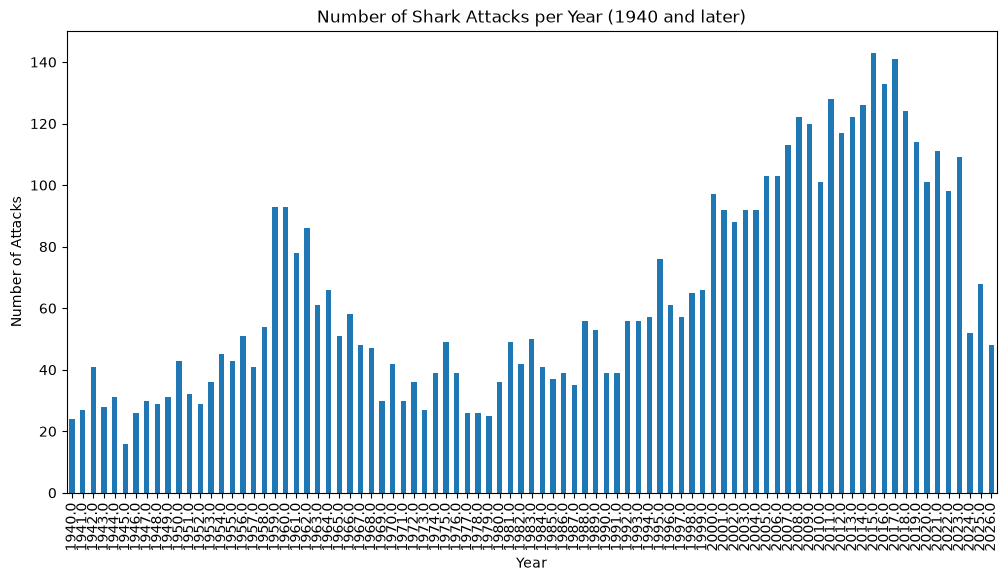

In [26]:
# Q2:
# 1. open the file
shark = pd.read_excel('./data/GSAF5.xls', engine = 'xlrd')
print("Original Shape: ", shark.shape)

# 2. drop the cols that have no data
shark.columns = shark.columns.astype(str).str.strip() # remove leading and trailing whitespace from column names
shark = shark.dropna(axis = 1, how = 'all')

# drop columns starts with unnamed
shark = shark.loc[:, ~shark.columns.str.startswith('Unnamed')]

# make cols lowercase
shark.columns = shark.columns.str.lower()

# 3. clean yr and focus on yrs since 1940
shark["year_cleaned"] = pd.to_numeric(shark["year"], errors = "coerce")

print("Year range: ", shark["year_cleaned"].min(), "to", shark["year_cleaned"].max())

shark_1940 = shark[shark["year_cleaned"] >= 1940]
attacks_per_year = (shark_1940["year_cleaned"].value_counts().sort_index())

attacks_per_year.plot(kind = "bar", figsize = (12, 6))
plt.title("Number of Shark Attacks per Year (1940 and later)")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")


The number of shark attacks increased over time from 1940.

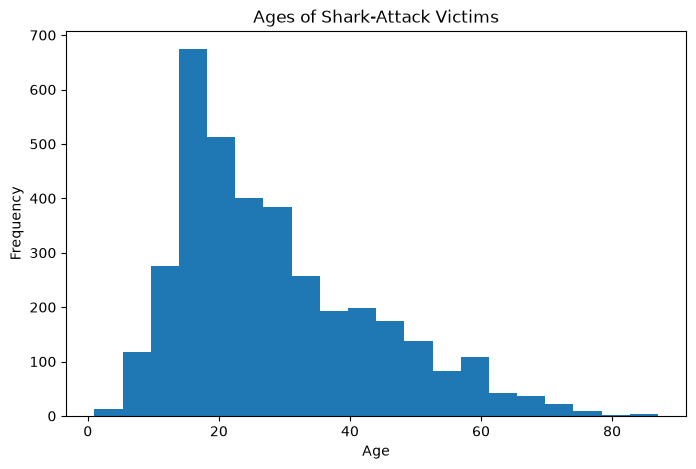

In [27]:
# 4. clean age and make a histogram
shark_1940["age_cleaned"] = pd.to_numeric(
    shark_1940["age"],
    errors="coerce"
)

shark_1940["age_cleaned"].dropna().plot.hist(
    bins=20,
    figsize=(8, 5)
)

plt.title("Ages of Shark-Attack Victims")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [28]:
# 5. proportion of male
shark_1940["sex_cleaned"] = shark_1940["sex"].str.strip().str.upper()

sex = shark_1940["sex_cleaned"].isin(["M", "F"])
male_percentage = (
    shark_1940.loc[sex, "sex_cleaned"] == "M"
).mean()

print("Proportion of male victims: ", male_percentage * 100, "%")

Proportion of male victims:  85.719867161555 %


The proportion of male victims by shark attacks is about 85.72 percent.

In [29]:
# 6. clean type
shark_1940["type_cleaned"] = (
    shark_1940["type"]
    .str.strip()
    .str.title()
)

shark_1940.loc[
    ~shark_1940["type_cleaned"].isin(["Provoked", "Unprovoked"]),
    "type_cleaned"
] = "Unknown"

print(shark_1940["type_cleaned"].value_counts())

unprovoked_proportion = (
    shark_1940["type_cleaned"] == "Unprovoked"
).mean()

print("Proportion unprovoked:", unprovoked_proportion)

type_cleaned
Unprovoked    4159
Unknown        890
Provoked       526
Name: count, dtype: int64
Proportion unprovoked: 0.7460089686098654


Proportion unprovoke is about 74.6 percent.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 1a039ed
- **AI tool and model used:** ChatGPT 5.5

### *Prompts used

1. Task: help revision my phase 1 work based on the homework requirements, provide suggestions on improvements that would make phase 1 code completely satisfy the homework requirements

2. For phase 2, what are the specific improvements I can make to my existing code in phase 1?


### *AI-proposed changes


1. Keep the Airbnb `Price` cleaning, but make the explanation more explicit about commas in prices above 999 and report the final missing count.
2. For `subject_injury`, calculate the missing proportion using actual missing values before relabeling them for display.
3. Add row percentages to the police cross-tab so missingness patterns can be compared across force types.
4. For shark years, describe the full cleaned range and note that `0` values represent invalid or unknown years.
5. Use `.copy()` after filtering shark attacks since 1940 to avoid chained-assignment warnings.
6. Support the shark-attack trend conclusion with numerical evidence, not only a plot.
7. Improve shark `Age` cleaning by recovering common nonstandard values such as `20s`, `30+`, `Teen`, and ranges.
8. State the denominator for the male-victim proportion and exclude unknown or ambiguous sex values.
9. Show before-and-after counts for shark `Type` and group all non-Provoked/Unprovoked values as `Unknown`.
10. Rerun the final solution from top to bottom so all plots, tables, proportions, and interpretations are visible.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | The original price conversion was correct, but the written explanation now directly addresses the comma-formatting issue and reports `0` missing values. |
| 2 | Accept | Missingness is now measured with `isna().mean()` before replacing missing values with a label for tables. |
| 3 | Accept | The revised solution includes both count and row-percentage cross-tabs, making force-type patterns easier to interpret. |
| 4 | Accept | The final solution reports the cleaned year range and separates invalid `0` years from the valid post-1940 analysis. |
| 5 | Accept | The filtered shark dataframe uses `.copy()` before adding cleaned variables. |
| 6 | Accept | The final trend answer uses a plot plus decade averages and a fitted yearly slope. |
| 7 | Modify | A fully perfect age parser is not necessary, but the revised function recovers common formats while leaving unclear values as missing. |
| 8 | Accept | The final answer calculates the male proportion among known `M`/`F` records only and reports that denominator. |
| 9 | Accept | The final solution prints raw and cleaned `Type` counts and calculates the unprovoked proportion after recoding. |
| 10 | Accept | The revised Phase 2 code is designed to run top-to-bottom and display all required outputs. |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.


In [1]:
# Phase 2 revised solution

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
# Q1.1: Clean Airbnb Price

airbnb = pd.read_csv("./data/airbnb_hw.csv")

price_raw = airbnb["Price"].astype("string").str.strip()
airbnb["price_cleaned"] = pd.to_numeric(
    price_raw.str.replace(",", "", regex=False),
    errors="coerce"
)

print("Raw Price dtype:", airbnb["Price"].dtype)
print("Cleaned price summary:")
display(airbnb["price_cleaned"].describe())
print("Missing cleaned prices:", airbnb["price_cleaned"].isna().sum())


Raw Price dtype: str
Cleaned price summary:
Missing cleaned prices: 0


count       30478.0
mean     163.589737
std      197.785454
min            10.0
25%            80.0
50%           125.0
75%           195.0
max         10000.0

For Airbnb, `Price` was stored as text because prices above 999 use commas, such as `1,112`. I removed commas, stripped extra spaces, and converted the result to numeric. The cleaned variable has `0` missing values.


In [3]:
# Q1.2: Clean Minnesota police subject_injury and cross-tabulate with force_type

police_data = pd.read_csv("./data/mn_police_use_of_force.csv")

injury_clean = police_data["subject_injury"].where(
    police_data["subject_injury"].isin(["Yes", "No"])
)
police_data["subject_injury_cleaned"] = injury_clean
police_data["subject_injury_for_table"] = injury_clean.fillna("Missing")

missing_prop = police_data["subject_injury_cleaned"].isna().mean()
print(f"Missing subject_injury proportion: {missing_prop:.3f} ({missing_prop * 100:.1f}%)")

injury_counts = pd.crosstab(
    police_data["force_type"],
    police_data["subject_injury_for_table"]
)
injury_row_pct = injury_counts.div(injury_counts.sum(axis=1), axis=0).mul(100).round(1)

print("Counts by force_type:")
display(injury_counts)

print("Row percentages by force_type:")
display(injury_row_pct)


Missing subject_injury proportion: 0.762 (76.2%)
Counts by force_type:
Row percentages by force_type:


subject_injury_for_table     Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm                            0     2     0
Gun Point Display                 27    33    44
Improvised Weapon                 74    34    40
Less Lethal                       87     0     0
Less Lethal Projectile             0     1     2
Maximal Restraint Technique      170     0     0
Police K9 Bite                    31     2    44
Taser                            985   150   172

subject_injury_for_table     Missing     No   Yes
force_type                                       
Baton                           50.0    0.0  50.0
Bodily Force                    74.8   11.6  13.6
Chemical Irritant               89.2    8.2   2.6
Firearm                          0.0  100.0   0.0
Gun Point Display               26.0   31.7  42.3
Improvised Weapon               50.0   23.0  27.0
Less Lethal                    100.0    0.0   0.0
Less Lethal Projectile           0.0   33.3  66.7
Maximal Restraint Technique    100.0    0.0   0.0
Police K9 Bite                  40.3    2.6  57.1
Taser                           75.4   11.5  13.2

About `76.2%` of `subject_injury` values are missing, which is a major concern because injury status is unavailable for most records. Missingness also depends on `force_type`: for example, `Chemical Irritant` has about `89.2%` missing, while `Gun Point Display` has about `26.0%` missing. Because missingness varies by force type, analyses using this variable could be biased.


In [4]:
# Q2.1 and Q2.2: Open shark attack Excel file and drop columns with no data

shark = pd.read_excel("./data/GSAF5.xls", engine="xlrd")
print("Original shape:", shark.shape)

shark.columns = shark.columns.astype(str).str.strip()
shark = shark.dropna(axis=1, how="all")
shark = shark.loc[:, ~shark.columns.str.startswith("Unnamed")]
shark.columns = shark.columns.str.lower()

print("Shape after dropping empty columns:", shark.shape)
print("Remaining columns:")
print(shark.columns.tolist())


Original shape: (7111, 23)
Shape after dropping empty columns: (7111, 21)
Remaining columns:
['date', 'year', 'type', 'country', 'state', 'location', 'activity', 'name', 'sex', 'age', 'injury', 'fatal y/n', 'time', 'species', 'source', 'pdf', 'href formula', 'href', 'case number', 'case number.1', 'original order']


Cleaned year range: 0.0 to 2026.0
Missing years: 2
Rows with year <= 0: 129
Average attacks/year in 1940-1949: 28.3
Average attacks/year in 2016-2025: 105.1
Linear fitted change per year: 0.98 attacks


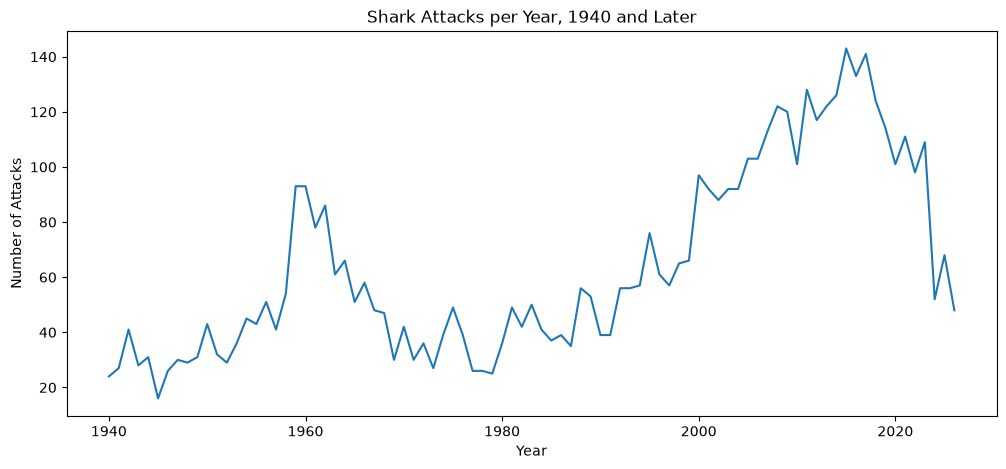

In [5]:
# Q2.3: Clean Year, filter to attacks since 1940, and assess trend

shark["year_cleaned"] = pd.to_numeric(shark["year"], errors="coerce")

print("Cleaned year range:", shark["year_cleaned"].min(), "to", shark["year_cleaned"].max())
print("Missing years:", shark["year_cleaned"].isna().sum())
print("Rows with year <= 0:", (shark["year_cleaned"] <= 0).sum())

shark_1940 = shark.loc[shark["year_cleaned"] >= 1940].copy()
shark_1940["year_cleaned"] = shark_1940["year_cleaned"].astype(int)

attacks_per_year = shark_1940.groupby("year_cleaned").size()

fig, ax = plt.subplots(figsize=(12, 5))
attacks_per_year.plot(ax=ax)
ax.set_title("Shark Attacks per Year, 1940 and Later")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Attacks")
plt.show()

slope = np.polyfit(attacks_per_year.index, attacks_per_year.values, 1)[0]
first_decade_avg = attacks_per_year.loc[1940:1949].mean()
latest_complete_year = min(2025, attacks_per_year.index.max())
latest_decade_start = latest_complete_year - 9
latest_decade_avg = attacks_per_year.loc[latest_decade_start:latest_complete_year].mean()

print(f"Average attacks/year in 1940-1949: {first_decade_avg:.1f}")
print(f"Average attacks/year in {latest_decade_start}-{latest_complete_year}: {latest_decade_avg:.1f}")
print(f"Linear fitted change per year: {slope:.2f} attacks")


The cleaned `year` values range from `0` to `2026`. The `0` values are not real years, so I filtered to attacks since 1940. Since 1940, reported shark attacks generally increase over time: the 1940s average is much lower than the most recent complete decade, and the fitted yearly slope is positive. The most recent year may be incomplete, so the long-run pattern is more reliable than the final bar or point alone.


Non-missing raw ages: 3798
Non-missing cleaned ages: 3749


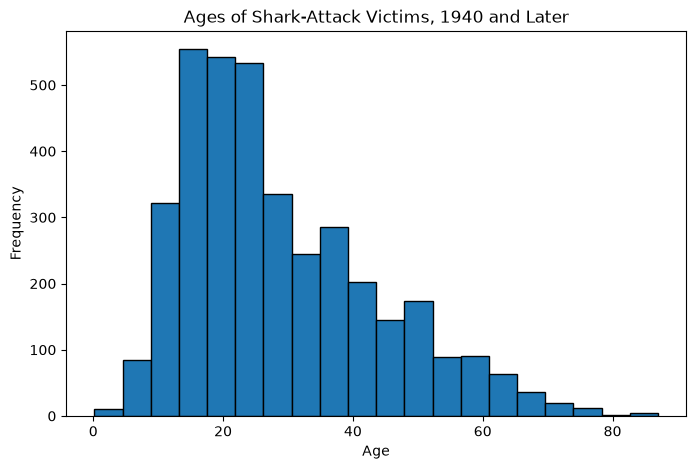

In [6]:
# Q2.4: Clean Age and make a histogram

def clean_age(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in {"", "?", "nan", "unknown", "x"}:
        return np.nan
    if "teen" in text:
        return 15
    if "minor" in text or "child" in text:
        return np.nan
    if "month" in text:
        month_nums = [int(x) for x in re.findall(r"\d{1,3}", text)]
        return month_nums[0] / 12 if month_nums else np.nan

    decade_match = re.fullmatch(r"(\d{1,2})'?s", text)
    if decade_match:
        return int(decade_match.group(1)) + 5

    plus_match = re.fullmatch(r"(\d{1,3})\+", text)
    if plus_match:
        return int(plus_match.group(1))

    nums = [int(x) for x in re.findall(r"\d{1,3}", text)]
    nums = [x for x in nums if 0 <= x <= 100]
    if not nums:
        return np.nan
    return float(np.mean(nums))

shark_1940["age_cleaned"] = shark_1940["age"].apply(clean_age)

print("Non-missing raw ages:", shark_1940["age"].notna().sum())
print("Non-missing cleaned ages:", shark_1940["age_cleaned"].notna().sum())

a = shark_1940["age_cleaned"].dropna()
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(a, bins=20, edgecolor="black")
ax.set_title("Ages of Shark-Attack Victims, 1940 and Later")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
plt.show()


The cleaned age variable converts standard numeric ages directly and recovers some common text formats, including decade labels like `20s`, plus signs like `30+`, and simple ranges by averaging the listed ages. Unclear entries remain missing. The histogram shows that victims are most commonly teenagers through middle-aged adults, with fewer very young or older victims.


In [7]:
# Q2.5: Proportion of victims who are male

shark_1940["sex_cleaned"] = shark_1940["sex"].astype("string").str.strip().str.upper()
known_sex = shark_1940["sex_cleaned"].isin(["M", "F"])

male_prop = (shark_1940.loc[known_sex, "sex_cleaned"] == "M").mean()
print("Known M/F records:", known_sex.sum())
print(f"Proportion male among known M/F records: {male_prop:.3f} ({male_prop * 100:.1f}%)")


Known M/F records: 5119
Proportion male among known M/F records: 0.857 (85.7%)


Among records with known `M` or `F` sex after 1940, about `85.7%` of victims are male. I excluded missing or ambiguous entries from the denominator.


In [8]:
# Q2.6: Clean Type into Provoked, Unprovoked, and Unknown

print("Raw Type counts:")
display(shark_1940["type"].astype("string").str.strip().value_counts(dropna=False))

shark_1940["type_cleaned"] = shark_1940["type"].astype("string").str.strip().str.title()
shark_1940.loc[
    ~shark_1940["type_cleaned"].isin(["Provoked", "Unprovoked"]),
    "type_cleaned"
] = "Unknown"

print("Cleaned Type counts:")
display(shark_1940["type_cleaned"].value_counts(dropna=False))

unprovoked_prop = (shark_1940["type_cleaned"] == "Unprovoked").mean()
print(f"Proportion unprovoked among all post-1940 records: {unprovoked_prop:.3f} ({unprovoked_prop * 100:.1f}%)")


Raw Type counts:
Cleaned Type counts:
Proportion unprovoked among all post-1940 records: 0.746 (74.6%)


type
Unprovoked             4157
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
<NA>                     14
Boat                      7
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1

type_cleaned
Unprovoked    4159
Unknown        890
Provoked       526

I recoded `Type` so the only values are `Provoked`, `Unprovoked`, and `Unknown`. Values such as `Invalid`, `Watercraft`, `Sea Disaster`, `Questionable`, blanks, and unverified cases are grouped as `Unknown`. About `74.6%` of post-1940 records are classified as unprovoked.


### *Reflection on AI assistance
In your own words without generative AI.


For phase 2 using AI to assist me to revise the previous code, I found that AI is especially well at making visualable plots and covering edge cases that humans noramlly miss. For example, in question 2.3, the plot that AI made for visualizing the number of shark attacks against the year is much more readable than the plot that I made. I made a thin histogra, while AI made a line graph that can better represent the trend of shark attacks over the years. Additionally, AI can help humans cover the edge cases that can be easily missed. For instance, in question 2.4, I used pd.to_numeric to coerce the age type, but it may turn many ages into missing values. In Phase 2, AI added a clean_age() function to address those hard to cover ages that are not numeric (eg. 20s becomes 25, 30+ becomes 30, teen becomes 15, etc). In phase 2, AI helped me cover another smaller edge case: for subject_injury, it calculates the missingness as true NaN first, and then only uses "Missing" as a display label for the cross-tab. 

However, AI is not perfect and has its downsides too. For example, AI assumed teen means age of 15, and 30+ were converted into 30, and 20s becomes 25. These might be fine, but we can not 100% be sure if these are what the intended ages are. I verified the revisions by rerunning all the Phase 2 cells, comparing the raw and cleaned value counts, confirming that the cleaned variables contained the expected categories, and inspecting the resulting tables and plots. Some concerns still remain: recent shark-attack data may be incomplete, the estimated ages are uncertain, and an increase in reported attacks does not necessarily mean that the actual rate of shark attacks increased.

Overall, AI is a great tool for debugging, suggesting improvements on wording, checking syntax errors, scanning codebase, and checking edge cases coverage, but AI has its own limitations and can possibly make errors that needs human provisioning and revisions.